<a href="https://colab.research.google.com/github/correctchemist/Systematic-Data-Collection-and-Curation/blob/main/Chalcone_Malaria_Data_filteration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Derived from 2024-12-07-malaria



# **Bioinformatics Project - CHALCONE**


### **CHALCONE FOR MALARIA**




## **Importing libraries**

In [10]:
# import dataset file
import pandas as pd
import numpy as np
df0 = pd.read_csv('/content/raw1.csv')
df0

,molecule_chembl_id,canonical_smiles,standard_relation,standard_units,standard_value,standard_type,units,value,strain
0,MB1,O=C(C1=CC=CC=C1OC)/C=C/C2=NC=CC=C2,=,nM,2000,IC50,uM,2,3D7
1,MB2,O=C(C1=CC=CC=C1OC)/C=C/C2=CC=CN=C2,=,nM,17380,IC50,uM,17.38,3D7
2,MB3,O=C(C1=CC=CC(OC)=C1)/C=C/C2=CC=CN=C2,=,nM,4090,IC50,uM,4.09,3D7
3,MB4,O=C(C1=CC=C(OC)C=C1)/C=C/C2=NC=CC=C2,=,nM,18640,IC50,uM,18.64,3D7
4,MB5,O=C(C1=CC=C(OC)C=C1)/C=C/C2=CC=CN=C2,=,nM,4470,IC50,uM,4.47,3D7
...,...,...,...,...,...,...,...,...,...
387,MB388,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,=,nM,11700,IC50,uM,11.7,Dd2
388,MB389,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,=,nM,300,IC50,uM,0.3,Dd2
389,MB390,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,=,nM,1900,IC50,uM,1.9,Dd2
390,MB391,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,=,nM,1600,IC50,uM,1.6,Dd2


In [11]:
df0.to_csv('chacone_00_bioactivity_data_raw.csv', index=False)

Here, only data that are reported as IC$_{50}$ values in nM (nanomolar) unit.

In [12]:
# # Filter rows where 'standard_units' is 'nM'
filtered_df = df0[df0['standard_units'] == 'nM']

# Display the filtered data
filtered_df.head()

df_IC50 = pd.DataFrame.from_dict(filtered_df)

df_IC50.to_csv('chalcone_01_bioactivity_IC50_data_raw.csv', index=False)

Finally we will save the resulting bioactivity data to a CSV file **bioactivity_data.csv**.

## **Handling missing data**
If any compounds has missing value for the **standard_value** column then drop it

In [13]:
#Remove missing data
df2_IC50 = df_IC50[df_IC50.standard_value.notna()]
df2_IC50 = df2_IC50[df_IC50.canonical_smiles.notna()]
df2_IC50

,molecule_chembl_id,canonical_smiles,standard_relation,standard_units,standard_value,standard_type,units,value,strain
0,MB1,O=C(C1=CC=CC=C1OC)/C=C/C2=NC=CC=C2,=,nM,2000,IC50,uM,2,3D7
1,MB2,O=C(C1=CC=CC=C1OC)/C=C/C2=CC=CN=C2,=,nM,17380,IC50,uM,17.38,3D7
2,MB3,O=C(C1=CC=CC(OC)=C1)/C=C/C2=CC=CN=C2,=,nM,4090,IC50,uM,4.09,3D7
3,MB4,O=C(C1=CC=C(OC)C=C1)/C=C/C2=NC=CC=C2,=,nM,18640,IC50,uM,18.64,3D7
4,MB5,O=C(C1=CC=C(OC)C=C1)/C=C/C2=CC=CN=C2,=,nM,4470,IC50,uM,4.47,3D7
...,...,...,...,...,...,...,...,...,...
387,MB388,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,=,nM,11700,IC50,uM,11.7,Dd2
388,MB389,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,=,nM,300,IC50,uM,0.3,Dd2
389,MB390,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,=,nM,1900,IC50,uM,1.9,Dd2
390,MB391,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,=,nM,1600,IC50,uM,1.6,Dd2


## **Data pre-processing of the bioactivity data**

### **Iterate *canonical_smiles* to a list**

In [14]:
#Remove duplicate data in canonical_smiles column
df2_nr_IC50 = df2_IC50.drop_duplicates(['canonical_smiles'])

### **Combine the 3 lists into a dataframe**

In [15]:
#Selecting 3 column for further analysis
selection = ['molecule_chembl_id','canonical_smiles','standard_value']
df3_IC50 = df2_nr_IC50[selection]

In [16]:
df3_IC50.to_csv('chalcone_02_bioactivity_IC50_data_preprocessed.csv', index=False)

In [17]:
df4_IC50 = pd.read_csv('chalcone_02_bioactivity_IC50_data_preprocessed.csv')

### **Labeling compounds as either being active, inactive or intermediate**
The bioactivity data is in the IC50 unit. Compounds having values of less than 1000 nM will be considered to be **active** while those greater than 10,000 nM will be considered to be **inactive**. As for those values in between 1,000 and 10,000 nM will be referred to as **intermediate**.

In [18]:
bioactivity_threshold = []
for i in df4_IC50.standard_value:
  if float(i) >= 10000:
    bioactivity_threshold.append("inactive")
  elif float(i) <= 1000:
    bioactivity_threshold.append("active")
  else:
    bioactivity_threshold.append("intermediate")

bioactivity_class = pd.Series(bioactivity_threshold, name='class')
df5_IC50 = pd.concat([df4_IC50, bioactivity_class], axis=1)

In [19]:
df5_IC50.to_csv('chalcone_03_bioactivity_IC50_data_curated.csv', index=False)

### 02_Exploratory analysis

In [20]:
#run with python 3.7
!pip install rdkit-pypi


ERROR: Could not find a version that satisfies the requirement rdkit-pypi (from versions: none)
ERROR: No matching distribution found for rdkit-pypi


In [21]:
import pandas as pd
df = pd.read_csv('/content/chalcone_03_bioactivity_IC50_data_curated.csv')
display(df.describe())

,standard_value
count,346.000000
mean,33169.221243
std,68843.663429
min,7.460000
25%,3985.000000
50%,14450.000000
75%,35117.500000
max,600000.000000


In [22]:
df

,molecule_chembl_id,canonical_smiles,standard_value,class
0,MB1,O=C(C1=CC=CC=C1OC)/C=C/C2=NC=CC=C2,2000.0,intermediate
1,MB2,O=C(C1=CC=CC=C1OC)/C=C/C2=CC=CN=C2,17380.0,inactive
2,MB3,O=C(C1=CC=CC(OC)=C1)/C=C/C2=CC=CN=C2,4090.0,intermediate
3,MB4,O=C(C1=CC=C(OC)C=C1)/C=C/C2=NC=CC=C2,18640.0,inactive
4,MB5,O=C(C1=CC=C(OC)C=C1)/C=C/C2=CC=CN=C2,4470.0,intermediate
...,...,...,...,...
341,MB388,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,11700.0,inactive
342,MB389,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,300.0,active
343,MB390,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,1900.0,intermediate
344,MB391,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,1600.0,intermediate


In [23]:
df_no_smiles = df.drop(columns='canonical_smiles')

In [24]:
smiles = []

for i in df.canonical_smiles.tolist():
  cpd = str(i).split('.')
  cpd_longest = max(cpd, key = len)
  smiles.append(cpd_longest)

smiles = pd.Series(smiles, name = 'canonical_smiles')

In [25]:
df_clean_smiles = pd.concat([df_no_smiles,smiles], axis=1)
df_clean_smiles

,molecule_chembl_id,standard_value,class,canonical_smiles
0,MB1,2000.0,intermediate,O=C(C1=CC=CC=C1OC)/C=C/C2=NC=CC=C2
1,MB2,17380.0,inactive,O=C(C1=CC=CC=C1OC)/C=C/C2=CC=CN=C2
2,MB3,4090.0,intermediate,O=C(C1=CC=CC(OC)=C1)/C=C/C2=CC=CN=C2
3,MB4,18640.0,inactive,O=C(C1=CC=C(OC)C=C1)/C=C/C2=NC=CC=C2
4,MB5,4470.0,intermediate,O=C(C1=CC=C(OC)C=C1)/C=C/C2=CC=CN=C2
...,...,...,...,...
341,MB388,11700.0,inactive,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...
342,MB389,300.0,active,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...
343,MB390,1900.0,intermediate,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...
344,MB391,1600.0,intermediate,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...


# **Calculate Lipinski descriptors**
Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the **druglikeness** of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the **Rule-of-Five** or **Lipinski's Rule**.

The Lipinski's Rule stated the following:
* Molecular weight < 500 Dalton
* Octanol-water partition coefficient (LogP) < 5
* Hydrogen bond donors < 5
* Hydrogen bond acceptors < 10

In [26]:
!pip install rdkit

In [27]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

### **Calculate descriptors**

In [28]:
# Inspired by: https://codeocean.com/explore/capsules?query=tag:data-curation

def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors

In [29]:
df_lipinski = lipinski(df.canonical_smiles)
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,239.274,2.9863,0.0,3.0
1,239.274,2.9863,0.0,3.0
2,239.274,2.9863,0.0,3.0
3,239.274,2.9863,0.0,3.0
4,239.274,2.9863,0.0,3.0
...,...,...,...,...
341,557.006,5.9698,0.0,9.0
342,587.032,5.9784,0.0,10.0
343,565.844,7.2594,0.0,7.0
344,514.944,6.0917,0.0,7.0


### **Combine DataFrames**

Let's take a look at the 2 DataFrames that will be combined.

In [30]:
df_combined = pd.concat([df,df_lipinski], axis=1)
df_combined

,molecule_chembl_id,canonical_smiles,standard_value,class,MW,LogP,NumHDonors,NumHAcceptors
0,MB1,O=C(C1=CC=CC=C1OC)/C=C/C2=NC=CC=C2,2000.0,intermediate,239.274,2.9863,0.0,3.0
1,MB2,O=C(C1=CC=CC=C1OC)/C=C/C2=CC=CN=C2,17380.0,inactive,239.274,2.9863,0.0,3.0
2,MB3,O=C(C1=CC=CC(OC)=C1)/C=C/C2=CC=CN=C2,4090.0,intermediate,239.274,2.9863,0.0,3.0
3,MB4,O=C(C1=CC=C(OC)C=C1)/C=C/C2=NC=CC=C2,18640.0,inactive,239.274,2.9863,0.0,3.0
4,MB5,O=C(C1=CC=C(OC)C=C1)/C=C/C2=CC=CN=C2,4470.0,intermediate,239.274,2.9863,0.0,3.0
...,...,...,...,...,...,...,...,...
341,MB388,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,11700.0,inactive,557.006,5.9698,0.0,9.0
342,MB389,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,300.0,active,587.032,5.9784,0.0,10.0
343,MB390,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,1900.0,intermediate,565.844,7.2594,0.0,7.0
344,MB391,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,1600.0,intermediate,514.944,6.0917,0.0,7.0


In [31]:
df_combined.to_csv('chalcone_03_bioactivity_lipsk.csv')

### **Convert IC50 to pIC50**
To allow **IC50** data to be more uniformly distributed, we will convert **IC50** to the negative logarithmic scale which is essentially **-log10(IC50)**.

This custom function pIC50() will accept a DataFrame as input and will:
* Take the IC50 values from the ``standard_value`` column and converts it from nM to M by multiplying the value by 10$^{-9}$
* Take the molar value and apply -log10
* Delete the ``standard_value`` column and create a new ``pIC50`` column

In [32]:
import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value_norm', axis=1)

    return x

Point to note: Values greater than 100,000,000 will be fixed at 100,000,000 otherwise the negative logarithmic value will become negative.

In [33]:
df_combined.standard_value.describe()

,standard_value
count,346.000000
mean,33169.221243
std,68843.663429
min,7.460000
25%,3985.000000
50%,14450.000000
75%,35117.500000
max,600000.000000


In [34]:
-np.log10( (10**-9)* 100000000 )

np.float64(1.0)

In [35]:
-np.log10( (10**-9)* 10000000000 )

np.float64(-1.0)

In [36]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop('standard_value', axis=1)

    return x

In [37]:
df_norm = norm_value(df_combined)
df_norm

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm
0,MB1,O=C(C1=CC=CC=C1OC)/C=C/C2=NC=CC=C2,intermediate,239.274,2.9863,0.0,3.0,2000.0
1,MB2,O=C(C1=CC=CC=C1OC)/C=C/C2=CC=CN=C2,inactive,239.274,2.9863,0.0,3.0,17380.0
2,MB3,O=C(C1=CC=CC(OC)=C1)/C=C/C2=CC=CN=C2,intermediate,239.274,2.9863,0.0,3.0,4090.0
3,MB4,O=C(C1=CC=C(OC)C=C1)/C=C/C2=NC=CC=C2,inactive,239.274,2.9863,0.0,3.0,18640.0
4,MB5,O=C(C1=CC=C(OC)C=C1)/C=C/C2=CC=CN=C2,intermediate,239.274,2.9863,0.0,3.0,4470.0
...,...,...,...,...,...,...,...,...
341,MB388,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,inactive,557.006,5.9698,0.0,9.0,11700.0
342,MB389,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,active,587.032,5.9784,0.0,10.0,300.0
343,MB390,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,intermediate,565.844,7.2594,0.0,7.0,1900.0
344,MB391,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,intermediate,514.944,6.0917,0.0,7.0,1600.0


In [38]:
df_norm.standard_value_norm.describe()

,standard_value_norm
count,346.000000
mean,33169.221243
std,68843.663429
min,7.460000
25%,3985.000000
50%,14450.000000
75%,35117.500000
max,600000.000000


In [39]:
df_final = pIC50(df_norm)
df_final

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,MB1,O=C(C1=CC=CC=C1OC)/C=C/C2=NC=CC=C2,intermediate,239.274,2.9863,0.0,3.0,5.698970
1,MB2,O=C(C1=CC=CC=C1OC)/C=C/C2=CC=CN=C2,inactive,239.274,2.9863,0.0,3.0,4.759950
2,MB3,O=C(C1=CC=CC(OC)=C1)/C=C/C2=CC=CN=C2,intermediate,239.274,2.9863,0.0,3.0,5.388277
3,MB4,O=C(C1=CC=C(OC)C=C1)/C=C/C2=NC=CC=C2,inactive,239.274,2.9863,0.0,3.0,4.729554
4,MB5,O=C(C1=CC=C(OC)C=C1)/C=C/C2=CC=CN=C2,intermediate,239.274,2.9863,0.0,3.0,5.349692
...,...,...,...,...,...,...,...,...
341,MB388,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,inactive,557.006,5.9698,0.0,9.0,4.931814
342,MB389,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,active,587.032,5.9784,0.0,10.0,6.522879
343,MB390,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,intermediate,565.844,7.2594,0.0,7.0,5.721246
344,MB391,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,intermediate,514.944,6.0917,0.0,7.0,5.795880


In [40]:
df_final.pIC50.describe()

,pIC50
count,346.000000
mean,5.118907
std,1.014426
min,3.221849
25%,4.454536
50%,4.840135
75%,5.399573
max,8.127261


Let's write this to CSV file.

In [41]:
df_final.to_csv('chalcone_04_bioactivity_data_3class_pIC50.csv')

### **Removing the 'intermediate' bioactivity class**
Here, we will be removing the ``intermediate`` class from our data set.

In [42]:
#Removing the 'intermediate' bioactivity class
df_2class = df_final[df_final['class']  != 'intermediate']
df_2class

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
1,MB2,O=C(C1=CC=CC=C1OC)/C=C/C2=CC=CN=C2,inactive,239.274,2.98630,0.0,3.0,4.759950
3,MB4,O=C(C1=CC=C(OC)C=C1)/C=C/C2=NC=CC=C2,inactive,239.274,2.98630,0.0,3.0,4.729554
6,MB7,OC1=CC(OC)=CC(OC)=C1C(/C=C/C2=CC=C(OCC3=CN(C4=...,inactive,539.947,5.26630,1.0,9.0,4.935168
9,MB10,OC1=CC(OC)=CC(OC)=C1C(/C=C/C2=CC=C(OCC3=CN(C4=...,inactive,521.957,5.12720,1.0,9.0,4.886725
12,MB13,OC1=CC(OC)=CC(OC)=C1C(/C=C/C2=CC=C(OC)C(OCC3=C...,inactive,539.947,5.26630,1.0,9.0,4.856361
...,...,...,...,...,...,...,...,...
334,MB381,O=C(C1=CC=C(OC)C=C1OC)/C=C/C2=CC=C(OCC3=CN(C4=...,active,557.006,5.96980,0.0,9.0,7.154902
335,MB382,O=C(C1=CC=C(OC)C(OC)=C1OC)/C=C/C2=CC=C(OCC3=CN...,active,587.032,5.97840,0.0,10.0,6.397940
336,MB383,O=C1NC(C(C)=CN1C2OC(CO)C(N3N=NC(COC4=CC=C(C(/C...,inactive,619.631,2.45852,2.0,13.0,4.928118
341,MB388,O=C(C1=CC=C(OCC2=CN(C3=CC=NC4=CC(Cl)=CC=C34)N=...,inactive,557.006,5.96980,0.0,9.0,4.931814


Let's write this to CSV file.

In [43]:
df_2class.to_csv('chalcone_05_bioactivity_data_2class_pIC50.csv')

## **Exploratory Data Analysis (Chemical Space Analysis) via Lipinski descriptors**

In [44]:
#Statistical
mean_MW = df_2class.groupby('class')["MW"].mean()
SD_MW = df_2class.groupby('class')["MW"].std()
mean_LogP = df_2class.groupby('class')["LogP"].mean()
SD_LogP = df_2class.groupby('class')["LogP"].std()
mean_NumHDonors = df_2class.groupby('class')["NumHDonors"].mean()
SD_NumHDonors = df_2class.groupby('class')["NumHDonors"].std()
mean_NumHAcceptors = df_2class.groupby('class')["NumHAcceptors"].mean()
SD_NumHAcceptors = df_2class.groupby('class')["NumHAcceptors"].std()

In [45]:
total = [mean_MW,SD_MW,mean_LogP,SD_LogP,mean_NumHDonors,SD_NumHDonors,mean_NumHAcceptors,SD_NumHAcceptors]
label=['meanMWac', 'meanMWin','SDMWac', 'SDMWin',
     'meanLogPac', 'meanLogPin','SDLogPac','SDLogPin',
     'meanNumHDonorsac','meanNumHDonorsin','SDNumHDonorsac','SDNumHDonorsin',
    'meanNumHAcceptorsac', 'meanNumHAcceptorsin','SDNumHAcceptorsac','SDNumHAcceptorsin']

In [46]:
statistic_Ro5 = pd.concat(total, axis=0)
Ro5 = pd.DataFrame(statistic_Ro5, columns=["stat"])
Ro5['label']= label
Ro5

,stat,label
class,,
active,538.167055,meanMWac
inactive,346.847704,meanMWin
active,56.340874,SDMWac
inactive,97.409202,SDMWin
active,6.978626,meanLogPac
inactive,4.537789,meanLogPin
active,1.283293,SDLogPac
inactive,1.087044,SDLogPin
active,1.636364,meanNumHDonorsac


In [47]:
Ro5.to_csv("Ro5_stat.csv",index=True)

### **Import library**

In [48]:
pip install statannotations

In [49]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

### **Frequency plot of the 2 bioactivity classes**

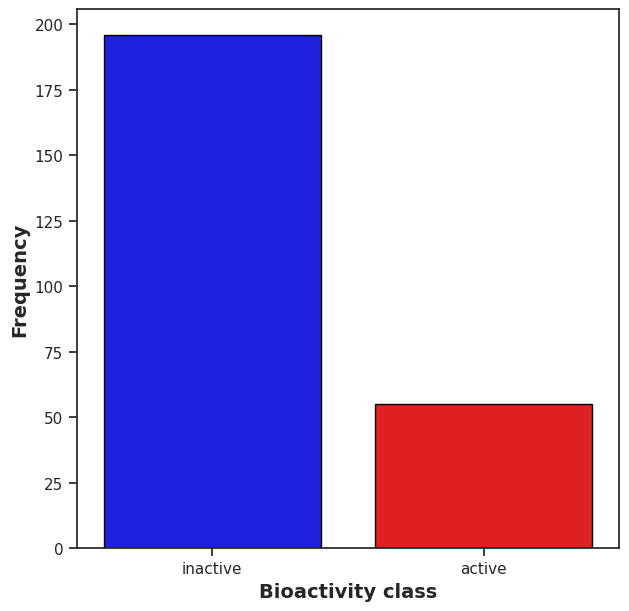

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set color palette and figure size
plt.figure(figsize=(7, 7))

# Assign `hue='class'` to resolve the warning
sns.countplot(x='class', data=df_2class, edgecolor='black',
              hue='class', palette=['blue', 'red'], legend=False)

# Customize axis labels
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

# Save the plot
plt.savefig('plot_bioactivity_class.tiff', bbox_inches='tight', pad_inches=0.1)


### **Scatter plot of MW versus LogP**

It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

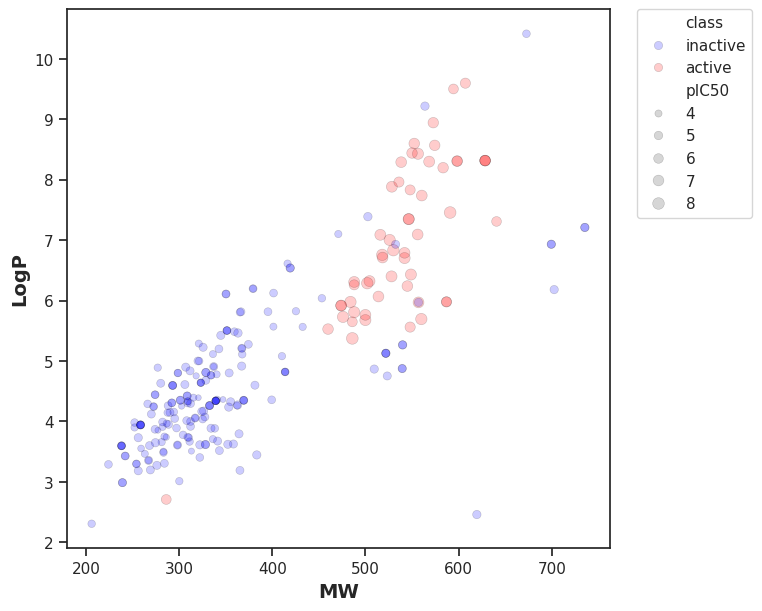

In [51]:
plt.figure(figsize=(7, 7))

sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='class', size='pIC50', edgecolor='black', alpha=0.2, palette=['blue', 'red'])
sns.set_style("whitegrid", {"ytick.major.size": 100,"xtick.major.size": 2, 'grid.linestyle': 'solid'})

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)

plt.savefig('plot_MW_vs_LogP.tiff', bbox_inches='tight', pad_inches=0.1)

### **Box plots**

#### **pIC50 value**

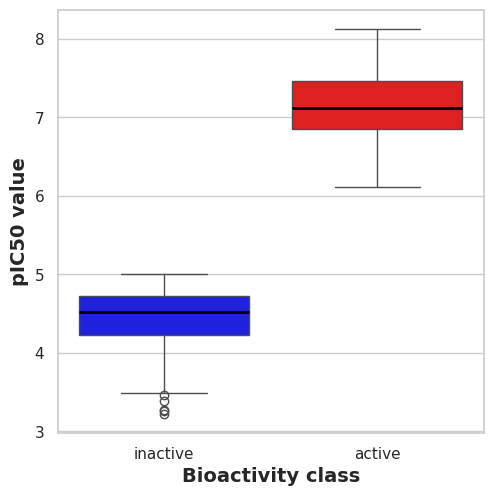

In [52]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x='class', y='pIC50', data=df_2class, medianprops=dict(color="black", alpha=1, linewidth=2), hue='class', palette=['blue', 'red'], legend=False)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_IC50.tiff')
plt.savefig('plot_ic50.pdf')

####  Statistical analysis | Mann-Whitney U Test

In [53]:
def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'class']
  df = df_2class[selection]
  active = df[df['class'] == 'active']
  active = active[descriptor]

  selection = [descriptor, 'class']
  df = df_2class[selection]
  inactive = df[df['class'] == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'

  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [54]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,10780.0,9.590094e-30,0.05,Different distribution (reject H0)


In [55]:
pip install statsmodels

In [56]:
from statannotations.Annotator import Annotator

#### MW

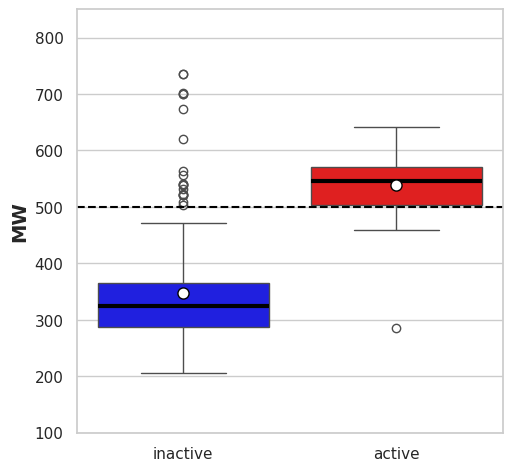

In [57]:
plt.figure(figsize=(5.5, 5.5))

ax = sns.boxplot(x='class', y='MW', data=df_2class, showmeans=True,  meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 8},
                 medianprops=dict(color="black", alpha=1, linewidth=3),
                 hue='class', palette=['blue', 'red'], legend=False)
ax.axhline(500, ls='--',c = 'black')
ax.set(ylim=(100, 850))
ax.set(xlabel=None)

plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.tiff')

In [58]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,9962.5,7.300678e-22,0.05,Different distribution (reject H0)


#### LogP

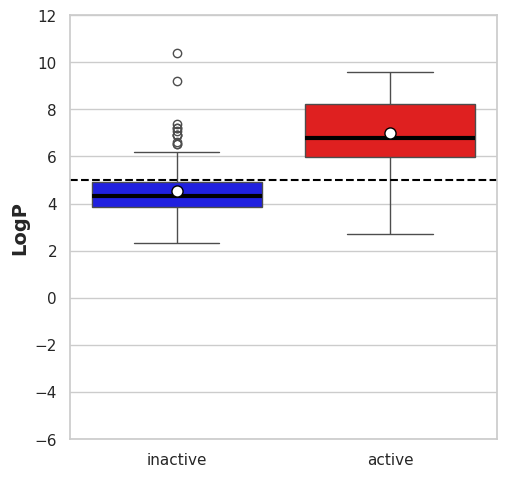

In [59]:
plt.figure(figsize=(5.5, 5.5))

ax = sns.boxplot(x='class', y='LogP', data=df_2class,
                 showmeans=True,
                 meanprops={"marker": "o", "markerfacecolor": "white",
                            "markeredgecolor": "black", "markersize": 8},
                 medianprops=dict(color="black", alpha=1, linewidth=3),
                 hue='class', palette=['blue', 'red'], legend=False)

ax.axhline(5, ls='--',c = 'black')
ax.set(ylim=(-6, 12))
ax.set(xlabel=None)

plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.tiff')

In [60]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,10030.0,1.822465e-22,0.05,Different distribution (reject H0)


#### NumHDonor

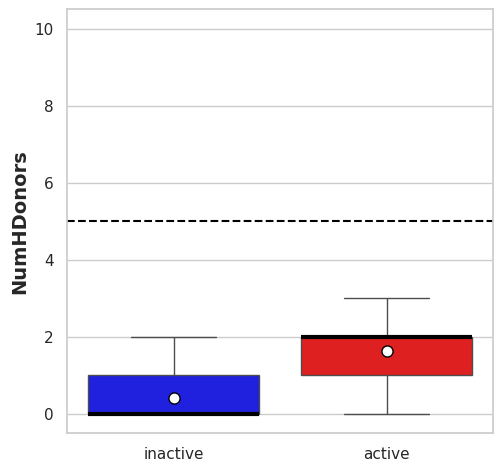

In [61]:
plt.figure(figsize=(5.5, 5.5))

ax = sns.boxplot(x='class', y='NumHDonors', data=df_2class,
                 showmeans=True,
                 meanprops={"marker": "o", "markerfacecolor": "white",
                            "markeredgecolor": "black", "markersize": 8},
                 medianprops=dict(color="black", alpha=1, linewidth=3),
                 hue='class', palette=['blue', 'red'])

ax.axhline(5, ls='--', c='black')  # Add a horizontal line
ax.set(ylim=(-0.5, 10.5))          # Set the y-axis limits
ax.set(xlabel=None)                # Remove the x-axis label

plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.tiff')


In [62]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,9317.5,9.942229e-20,0.05,Different distribution (reject H0)


#### NumHAcceptors

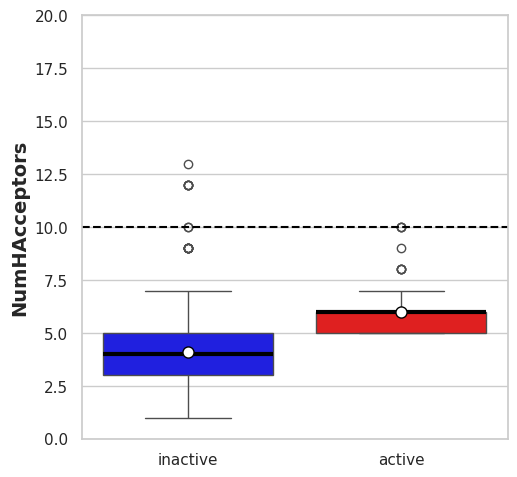

In [63]:
plt.figure(figsize=(5.5, 5.5))

ax = sns.boxplot(x='class', y='NumHAcceptors', data=df_2class,
                 showmeans=True,
                 meanprops={"marker": "o", "markerfacecolor": "white",
                            "markeredgecolor": "black", "markersize": 8},
                 medianprops=dict(color="black", alpha=1, linewidth=3),
                 hue='class', palette=['blue', 'red'])

# Add horizontal line and customize axes
ax.axhline(10, ls='--', c='black')  # Horizontal line at y=10
ax.set(ylim=(0, 20))                # Set y-axis range
ax.set(xlabel=None)                 # Remove x-axis label

# Customize y-axis label
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

# Save the figure
plt.savefig('plot_NumHAcceptors.tiff')


In [64]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,9028.5,8.342247e-15,0.05,Different distribution (reject H0)


## **Zip files**

In [65]:
!ls

chacone_00_bioactivity_data_raw.csv		    plot_bioactivity_class.tiff
chalcone_01_bioactivity_IC50_data_raw.csv	    plot_ic50.pdf
chalcone_02_bioactivity_IC50_data_preprocessed.csv  plot_IC50.tiff
chalcone_03_bioactivity_IC50_data_curated.csv	    plot_LogP.tiff
chalcone_03_bioactivity_lipsk.csv		    plot_MW.tiff
chalcone_04_bioactivity_data_3class_pIC50.csv	    plot_MW_vs_LogP.tiff
chalcone_05_bioactivity_data_2class_pIC50.csv	    plot_NumHAcceptors.tiff
mannwhitneyu_LogP.csv				    plot_NumHDonors.tiff
mannwhitneyu_MW.csv				    raw1.csv
mannwhitneyu_NumHAcceptors.csv			    Ro5_stat.csv
mannwhitneyu_NumHDonors.csv			    sample_data
mannwhitneyu_pIC50.csv


In [66]:
!zip -r results.zip . -i *.csv *.tiff

  adding: plot_IC50.tiff (deflated 99%)
  adding: mannwhitneyu_MW.csv (deflated 7%)
  adding: mannwhitneyu_LogP.csv (deflated 9%)
  adding: chalcone_03_bioactivity_IC50_data_curated.csv (deflated 85%)
  adding: chalcone_04_bioactivity_data_3class_pIC50.csv (deflated 77%)
  adding: mannwhitneyu_NumHDonors.csv (deflated 10%)
  adding: raw1.csv (deflated 84%)
  adding: Ro5_stat.csv (deflated 57%)
  adding: plot_LogP.tiff (deflated 99%)
  adding: mannwhitneyu_pIC50.csv (deflated 11%)
  adding: plot_NumHAcceptors.tiff (deflated 99%)
  adding: plot_MW.tiff (deflated 99%)
  adding: chalcone_03_bioactivity_lipsk.csv (deflated 80%)
  adding: plot_NumHDonors.tiff (deflated 99%)
  adding: chalcone_02_bioactivity_IC50_data_preprocessed.csv (deflated 83%)
  adding: plot_bioactivity_class.tiff (deflated 99%)
  adding: chalcone_05_bioactivity_data_2class_pIC50.csv (deflated 76%)
  adding: chalcone_01_bioactivity_IC50_data_raw.csv (deflated 83%)
  adding: mannwhitneyu_NumHAcceptors.csv (deflated 10%)
